# Ingeniería del Dato: BASE 1 - María Duque Laredo

## Carga de librerías

In [21]:
import pandas as pd
from pathlib import Path

import pandas as pd 
from functools import reduce

import seaborn as sns

import matplotlib.pyplot as plt

import seaborn as sns

## Dataset 1: Renta per cápita por CCAA

In [2]:
# Carga del dataset 1: Renta per cápita por CCAA (INE)

renta_ccaa = pd.read_csv("../raw/rentapercapita.csv", 
                         sep="\t", 
                         encoding="latin-1")

# Renombramos columnas

renta_ccaa = renta_ccaa.rename(columns={
    "Comunidades y Ciudades Autónomas": "ccaa",
    "Periodo": "year",
    "Total": "renta_pc"})

# Eliminamos columna del indicardor, no es relevante

renta_ccaa = renta_ccaa.drop(
    columns=["Renta anual neta media por persona y por unidad de consumo"]
)

# Limpiamos las Comunidades Autónomas
# 1. Eliminamos el código numérico delante de la CCAA

renta_ccaa["ccaa"] = renta_ccaa["ccaa"].str.replace(
    r"^\d+\s", "", regex=True
)

# 2. Normalizamos los nombres de las CCAA

reemplazos = {
    "Asturias, Principado de": "Asturias",
    "Balears, Illes": "Islas Baleares",
    "Castilla-La Mancha": "Castilla La Mancha",
    "Madrid, Comunidad de": "Madrid",
    "Murcia, Región de": "Murcia",
    "Navarra, Comunidad Foral de": "Navarra",
    "Rioja, La": "La Rioja",
    "Comunitat Valenciana": "Comunidad Valenciana",
    "Andalucía": "Andalucia",
    "Aragón": "Aragon",
    "Castilla y León": "Castilla y Leon",
    "País Vasco": "Pais Vasco"

}

renta_ccaa["ccaa"] = renta_ccaa["ccaa"].replace(reemplazos)

# Convertimos tipo de datos

renta_ccaa["year"] = pd.to_numeric(renta_ccaa["year"], errors="coerce")
renta_ccaa["renta_pc"] = pd.to_numeric(renta_ccaa["renta_pc"], errors="coerce")

# Ordenamos el dataset por las CCAA y año

renta_ccaa = renta_ccaa.sort_values(
    ["ccaa", "year"]
).reset_index(drop=True)

# Verificamos que no existen duplicados

print(
    "Duplicados:",
    renta_ccaa.duplicated(subset=["ccaa", "year"]).sum()
)

# Visualizamos del dataset limpio

display(renta_ccaa)

# Guardamos el dataset limpio

renta_ccaa.to_csv(
    "../processed/renta_ccaa_clean.csv",
    index=False
)

Duplicados: 0


,ccaa,year,renta_pc
0,Andalucia,2019,9.160
1,Andalucia,2020,9.990
2,Andalucia,2021,9.915
3,Andalucia,2022,10.703
4,Andalucia,2023,11.719
...,...,...,...
128,Pais Vasco,2021,15.544
129,Pais Vasco,2022,16.427
130,Pais Vasco,2023,18.189
131,Pais Vasco,2024,19.078


## Dataset 2: Formación alcanzada por CCAA

In [3]:
# Carga del dataset 2: Formación alcanzada por CCAA (INE)

formacion_ccaa = pd.read_csv(
    "../raw/formacion_ccaa.csv",
    sep="\t",
    encoding="latin-1"
)

# Renombramos las columnas

formacion_ccaa = formacion_ccaa.rename(columns={
    "Comunidades y Ciudades Autónomas": "ccaa",
    "Sexo": "sexo",
    "Nivel de formación alcanzado": "nivel_formacion",
    "Periodo": "periodo",
    "Total": "pct_poblacion_nivel_formacion"
})

# Limpiamos la variable 'ccaa'
#  1 Eliminamos el código numérico delante de la CCAA
#  2 Normalizamos los nombres de las comunidades autónomas

formacion_ccaa["ccaa"] = formacion_ccaa["ccaa"].str.replace(
    r"^\d+\s", "", regex=True
)

reemplazos = {
    "Asturias, Principado de": "Asturias",
    "Balears, Illes": "Islas Baleares",
    "Castilla-La Mancha": "Castilla La Mancha",
    "Madrid, Comunidad de": "Madrid",
    "Murcia, Región de": "Murcia",
    "Navarra, Comunidad Foral de": "Navarra",
    "Rioja, La": "La Rioja",
    "Comunitat Valenciana": "Comunidad Valenciana",
    "Andalucía": "Andalucia",
    "Aragón": "Aragon",
    "Castilla y León": "Castilla y Leon",
    "País Vasco": "Pais Vasco"
}

formacion_ccaa["ccaa"] = formacion_ccaa["ccaa"].replace(reemplazos)

# Limpiamos la variable 'sexo'
#  1 Pasamos a minúsculas y eliminamos espacios
#  2 Convertimos a singular

formacion_ccaa["sexo"] = formacion_ccaa["sexo"].str.lower().str.strip()

formacion_ccaa["sexo"] = formacion_ccaa["sexo"].replace({
    "hombres": "hombre",
    "mujeres": "mujer"
})

# Limpiamos y transformamos las variables 'periodo' y 'pct_poblacion_nivel_formacion'
#  1 Extraemos el año de la variable 'periodo'
#  2 Convertimos la variable de porcentaje a numérica

formacion_ccaa["year"] = formacion_ccaa["periodo"].str[:4]

formacion_ccaa["year"] = pd.to_numeric(
    formacion_ccaa["year"],
    errors="coerce"
)

formacion_ccaa["pct_poblacion_nivel_formacion"] = (
    formacion_ccaa["pct_poblacion_nivel_formacion"]
    .str.replace(",", ".", regex=False)
)

formacion_ccaa["pct_poblacion_nivel_formacion"] = pd.to_numeric(
    formacion_ccaa["pct_poblacion_nivel_formacion"],
    errors="coerce"
)

# Calculamos la media anual de los 4 trimestres para homogeneizar la frecuencia temporal del dataset

formacion_ccaa = formacion_ccaa.groupby(
    ["ccaa", "sexo", "nivel_formacion", "year"],
    as_index=False
)["pct_poblacion_nivel_formacion"].mean()

# Identificamos los diferentes niveles educativos

print("Niveles educativos en el dataset:")
print(formacion_ccaa["nivel_formacion"].unique())

print(
    formacion_ccaa["nivel_formacion"]
    .value_counts()
)

# Ordenamos el dataset en formato largo

formacion_ccaa = formacion_ccaa.sort_values(
    ["ccaa", "year", "sexo", "nivel_formacion"]
).reset_index(drop=True)

# Verificamos que no existen duplicados

print(
    "Duplicados en formato largo:",
    formacion_ccaa.duplicated(
        ["ccaa", "year", "sexo", "nivel_formacion"]
    ).sum()
)

# Transformamos el dataset a formato ancho (pivot)

formacion_ccaa_pivot = formacion_ccaa.pivot_table(
    index=["ccaa", "year", "sexo"],
    columns="nivel_formacion",
    values="pct_poblacion_nivel_formacion"
).reset_index()

# Eliminamos el nombre del índice de columnas
formacion_ccaa_pivot.columns.name = None

# Renombramos las columnas resultantes del pivot

formacion_ccaa_pivot = formacion_ccaa_pivot.rename(columns={
    "Analfabetos": "pct_analfabetos",
    "Educación primaria": "pct_educacion_primaria",
    "Educación superior": "pct_educacion_superior",
    "Estudios primarios incompletos": "pct_primarios_incompletos",
    "Primera etapa de Educación Secundaria y similar": "pct_primera_etapa_secundaria",
    "Segunda etapa de educación secundaria con orientación profesional (incluye educación postsecundaria no superior)": "pct_secundaria_profesional",
    "Segunda etapa de educación secundaria, con orientación general": "pct_secundaria_general"
})

# Ordenamos el dataset en formato ancho

formacion_ccaa_pivot = formacion_ccaa_pivot.sort_values(
    ["ccaa", "year", "sexo"]
).reset_index(drop=True)

# Verificamos que no existen duplicados en el formato final

print(
    "Duplicados en formato ancho:",
    formacion_ccaa_pivot.duplicated(
        ["ccaa", "year", "sexo"]
    ).sum()
)

# Visualizamos el dataset final limpio

display(formacion_ccaa_pivot)
print(formacion_ccaa_pivot.info())

# Guardamos el dataset limpio y pivotado

formacion_ccaa_pivot.to_csv(
    "../processed/formacion_ccaa_clean.csv",
    index=False
)

Niveles educativos en el dataset:
<StringArray>
[                                                                                                     'Analfabetos',
                                                                                               'Educación primaria',
                                                                                               'Educación superior',
                                                                                   'Estudios primarios incompletos',
                                                                  'Primera etapa de Educación Secundaria y similar',
 'Segunda etapa de educación secundaria con orientación profesional (incluye educación postsecundaria no superior)',
                                                   'Segunda etapa de educación secundaria, con orientación general']
Length: 7, dtype: str
nivel_formacion
Analfabetos                                                                                    

,ccaa,year,sexo,pct_analfabetos,pct_educacion_primaria,pct_educacion_superior,pct_primarios_incompletos,pct_primera_etapa_secundaria,pct_secundaria_profesional,pct_secundaria_general
0,Andalucia,2014,hombre,2.625,14.950,21.125,8.825,33.650,6.950,11.875
1,Andalucia,2014,mujer,4.850,14.275,22.400,10.875,28.675,7.500,11.350
2,Andalucia,2015,hombre,2.225,14.125,21.675,9.000,33.650,6.975,12.400
3,Andalucia,2015,mujer,4.775,13.675,23.175,10.800,28.225,7.625,11.775
4,Andalucia,2016,hombre,1.925,13.350,22.325,8.700,34.250,7.075,12.375
...,...,...,...,...,...,...,...,...,...,...
451,Pais Vasco,2023,mujer,1.075,12.275,43.650,2.675,19.000,9.550,11.750
452,Pais Vasco,2024,hombre,0.475,7.475,45.650,1.050,21.125,11.225,13.050
453,Pais Vasco,2024,mujer,1.225,12.175,43.125,2.525,17.925,10.175,12.875
454,Pais Vasco,2025,hombre,0.600,7.850,44.750,1.125,20.500,12.000,13.175


<class 'pandas.DataFrame'>
RangeIndex: 456 entries, 0 to 455
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ccaa                          456 non-null    str    
 1   year                          456 non-null    int64  
 2   sexo                          456 non-null    str    
 3   pct_analfabetos               456 non-null    float64
 4   pct_educacion_primaria        456 non-null    float64
 5   pct_educacion_superior        456 non-null    float64
 6   pct_primarios_incompletos     456 non-null    float64
 7   pct_primera_etapa_secundaria  456 non-null    float64
 8   pct_secundaria_profesional    456 non-null    float64
 9   pct_secundaria_general        456 non-null    float64
dtypes: float64(7), int64(1), str(2)
memory usage: 35.8 KB
None


## Dataset 3: Tasa bruta que finaliza la ESO 

In [4]:
# Carga del dataset 3: Tasa bruta que finaliza la ESO (EducaBase)

tasabruta_ESO = pd.read_csv("../raw/tasabruta_ESO.csv", 
                         sep="\t", 
                         encoding="latin-1")

# Renombramos las columnas

tasabruta_ESO = tasabruta_ESO.rename(columns= {
    "Comunidad autónoma": "ccaa",
    "Sexo": "sexo",
    "Total": "tasa_bruta_eso"})

# Normalizamos los nombres de las CCAA

reemplazos = {
    "Asturias, Principado de": "Asturias",
    "Balears, Illes": "Islas Baleares",
    "Castilla-La Mancha": "Castilla La Mancha",
    "Madrid, Comunidad de": "Madrid",
    "Murcia, Región de": "Murcia",
    "Navarra, Comunidad Foral de": "Navarra",
    "Rioja, La": "La Rioja",
    "Comunitat Valenciana": "Comunidad Valenciana",
    "Andalucía": "Andalucia",
    "Aragón": "Aragon",
    "Castilla y León": "Castilla y Leon",
    "País Vasco": "Pais Vasco"

}

tasabruta_ESO["ccaa"] = tasabruta_ESO["ccaa"].replace(reemplazos)

# Limpiamos y homogenizamos la variable 'sexo' para que todos los dataset tengan la misma estructura

tasabruta_ESO["sexo"] = tasabruta_ESO["sexo"].str.lower().str.strip()

tasabruta_ESO["sexo"] = tasabruta_ESO["sexo"].replace({
    "hombres": "hombre",
    "mujeres": "mujer"})

# Extraemos de la variable 'periodo' el año inicial del periodo

tasabruta_ESO["year"] = tasabruta_ESO["periodo"].str[:4]

tasabruta_ESO["year"] = pd.to_numeric(tasabruta_ESO["year"],
                                                    errors="coerce")

# Eliminamos la variable 'periodo' como estamos usando la creada 'year'

tasabruta_ESO = tasabruta_ESO.drop(columns=["periodo"])

# Convertimos la tasa bruta que finaliza la ESO a numérico

tasabruta_ESO["tasa_bruta_eso"] = (
    tasabruta_ESO["tasa_bruta_eso"]
    .str.replace(",", ".", regex=False)
)

tasabruta_ESO["tasa_bruta_eso"] = pd.to_numeric(
    tasabruta_ESO["tasa_bruta_eso"],
    errors="coerce"
)

# Ordenamos el dataset para que se parezca al resto y sea más fácil el merge

tasabruta_ESO = tasabruta_ESO.sort_values(
    ["ccaa", "year", "sexo", "tasa_bruta_eso"]
).reset_index(drop=True)

tasabruta_ESO = tasabruta_ESO[["ccaa", "year", "sexo", "tasa_bruta_eso"]]

# Verificamos que no existen duplicados

print(
    "Duplicados:",
    tasabruta_ESO.duplicated(
        ["ccaa", "year", "sexo", "tasa_bruta_eso"]
    ).sum()
)

# Visualizamos del dataset limpio

display(tasabruta_ESO)

# Guardamos el dataset limpio

tasabruta_ESO.to_csv(
    "../processed/tasabruta_ESO_clean.csv",
    index=False
)


Duplicados: 0


,ccaa,year,sexo,tasa_bruta_eso
0,Andalucia,1999,hombre,65.8
1,Andalucia,1999,mujer,81.2
2,Andalucia,2000,hombre,66.2
3,Andalucia,2000,mujer,79.9
4,Andalucia,2001,hombre,59.0
...,...,...,...,...
907,Pais Vasco,2020,mujer,92.2
908,Pais Vasco,2021,hombre,83.5
909,Pais Vasco,2021,mujer,90.4
910,Pais Vasco,2022,hombre,83.6


## Dataset 4: Tasa neta que finaliza la ESO 

In [5]:
# Carga del dataset 4: Tasa neta que finaliza la ESO (EducaBase)

tasaneta_ESO = pd.read_csv("../raw/tasaneta_ESO.csv", 
                         sep="\t", 
                         encoding="latin-1")

# Renombramos las columnas

tasaneta_ESO = tasaneta_ESO.rename(columns= {
    "Comunidad autónoma": "ccaa",
    "Sexo": "sexo",
    "Total": "tasa_neta_eso"})

# Normalizamos los nombres de las CCAA

reemplazos = {
    "Asturias, Principado de": "Asturias",
    "Balears, Illes": "Islas Baleares",
    "Castilla-La Mancha": "Castilla La Mancha",
    "Madrid, Comunidad de": "Madrid",
    "Murcia, Región de": "Murcia",
    "Navarra, Comunidad Foral de": "Navarra",
    "Rioja, La": "La Rioja",
    "Comunitat Valenciana": "Comunidad Valenciana",
    "Andalucía": "Andalucia",
    "Aragón": "Aragon",
    "Castilla y León": "Castilla y Leon",
    "País Vasco": "Pais Vasco"

}

tasaneta_ESO["ccaa"] = tasaneta_ESO["ccaa"].replace(reemplazos)

# Limpiamos y homogenizamos la variable 'sexo' para que todos los dataset tengan la misma estructura

tasaneta_ESO["sexo"] = tasaneta_ESO["sexo"].str.lower().str.strip()

tasaneta_ESO["sexo"] = tasaneta_ESO["sexo"].replace({
    "hombres": "hombre",
    "mujeres": "mujer"})

# Extraemos de la variable 'periodo' el año inicial del periodo

tasaneta_ESO["year"] = tasaneta_ESO["periodo"].str[:4]

tasaneta_ESO["year"] = pd.to_numeric(tasaneta_ESO["year"],
                                                    errors="coerce")

# Eliminamos la variable 'periodo' como estamos usando la creada 'year'

tasaneta_ESO = tasaneta_ESO.drop(columns=["periodo"])

# Convertimos la tasa neta que finaliza la ESO a numérico

tasaneta_ESO["tasa_neta_eso"] = (
    tasaneta_ESO["tasa_neta_eso"]
    .str.replace(",", ".", regex=False)
)

tasaneta_ESO["tasa_neta_eso"] = pd.to_numeric(
    tasaneta_ESO["tasa_neta_eso"],
    errors="coerce"
)

# Ordenamos el dataset para que se parezca al resto y sea más fácil el merge

tasaneta_ESO = tasaneta_ESO.sort_values(
    ["ccaa", "year", "sexo", "tasa_neta_eso"]
).reset_index(drop=True)

tasaneta_ESO = tasaneta_ESO[["ccaa", "year", "sexo", "tasa_neta_eso"]]

# Verificamos que no existen duplicados

print(
    "Duplicados:",
    tasaneta_ESO.duplicated(
        ["ccaa", "year", "sexo", "tasa_neta_eso"]
    ).sum()
)

# Visualizamos del dataset limpio

display(tasaneta_ESO)

# Guardamos el dataset limpio

tasaneta_ESO.to_csv(
    "../processed/tasaneta_ESO_clean.csv",
    index=False
)


Duplicados: 0


,ccaa,year,sexo,tasa_neta_eso
0,Andalucia,2016,hombre,68.1
1,Andalucia,2016,mujer,80.6
2,Andalucia,2017,hombre,69.7
3,Andalucia,2017,mujer,81.6
4,Andalucia,2018,hombre,71.7
...,...,...,...,...
223,Pais Vasco,2019,mujer,87.9
224,Pais Vasco,2020,hombre,86.8
225,Pais Vasco,2020,mujer,92.1
226,Pais Vasco,2021,hombre,83.1


## Dataset 5: Tasa bruta que finaliza Bachillerato

In [6]:
# Carga del dataset 5: Tasa bruta de graduados de Bachillerato (EducaBase)

tasabruta_bach = pd.read_csv("../raw/tasabruta_Bach.csv", 
                             sep="\t", 
                             encoding="latin-1")

# Renombramos las columnas

tasabruta_bach = tasabruta_bach.rename(columns={
    "Comunidad autónoma": "ccaa",
    "Sexo": "sexo",
    "Total": "tasa_bruta_bach"
})

# Normalizamos los nombres de las CCAA

reemplazos = {
    "Asturias, Principado de": "Asturias",
    "Balears, Illes": "Islas Baleares",
    "Castilla-La Mancha": "Castilla La Mancha",
    "Madrid, Comunidad de": "Madrid",
    "Murcia, Región de": "Murcia",
    "Navarra, Comunidad Foral de": "Navarra",
    "Rioja, La": "La Rioja",
    "Comunitat Valenciana": "Comunidad Valenciana",
    "Andalucía": "Andalucia",
    "Aragón": "Aragon",
    "Castilla y León": "Castilla y Leon",
    "País Vasco": "Pais Vasco"

}

tasabruta_bach["ccaa"] = tasabruta_bach["ccaa"].replace(reemplazos)

# Limpiamos y homogenizamos la variable 'sexo' para que todos los dataset tengan la misma estructura

tasabruta_bach["sexo"] = tasabruta_bach["sexo"].str.lower().str.strip()

tasabruta_bach["sexo"] = tasabruta_bach["sexo"].replace({
    "hombres": "hombre",
    "mujeres": "mujer"
})

# Extraemos de la variable 'periodo' el año inicial del periodo

tasabruta_bach["year"] = tasabruta_bach["periodo"].str[:4]

tasabruta_bach["year"] = pd.to_numeric(
    tasabruta_bach["year"],
    errors="coerce"
)

# Eliminamos la variable 'periodo' como estamos usando la creada 'year'

tasabruta_bach = tasabruta_bach.drop(columns=["periodo"])

# Convertimos la tasa bruta de graduados de Bachillerato a numérico

tasabruta_bach["tasa_bruta_bach"] = (
    tasabruta_bach["tasa_bruta_bach"]
    .str.replace(",", ".", regex=False)
)

tasabruta_bach["tasa_bruta_bach"] = pd.to_numeric(
    tasabruta_bach["tasa_bruta_bach"],
    errors="coerce"
)

# Ordenamos el dataset para que se parezca al resto y sea más fácil el merge

tasabruta_bach = tasabruta_bach.sort_values(
    ["ccaa", "year", "sexo", "tasa_bruta_bach"]
).reset_index(drop=True)

tasabruta_bach = tasabruta_bach[["ccaa", "year", "sexo", "tasa_bruta_bach"]]

# Verificamos que no existen duplicados

print(
    "Duplicados:",
    tasabruta_bach.duplicated(
        ["ccaa", "year", "sexo", "tasa_bruta_bach"]
    ).sum()
)

# Visualizamos el dataset limpio

display(tasabruta_bach)

# Guardamos el dataset limpio

tasabruta_bach.to_csv(
    "../processed/tasabruta_bach_clean.csv",
    index=False
)

Duplicados: 0


,ccaa,year,sexo,tasa_bruta_bach
0,Andalucia,1990,hombre,27.7
1,Andalucia,1990,mujer,33.2
2,Andalucia,1991,hombre,24.3
3,Andalucia,1991,mujer,30.9
4,Andalucia,1992,hombre,26.8
...,...,...,...,...
1249,Pais Vasco,2020,mujer,76.3
1250,Pais Vasco,2021,hombre,59.4
1251,Pais Vasco,2021,mujer,76.4
1252,Pais Vasco,2022,hombre,59.1


## Dataset 6: Tasa neta que finaliza Bachillerato

In [7]:
# Carga del dataset: Tasa neta de graduados de Bachillerato (EducaBase)

tasaneta_bach = pd.read_csv("../raw/tasaneta_bach.csv", 
                            sep="\t", 
                            encoding="latin-1")

# Renombramos las columnas

tasaneta_bach = tasaneta_bach.rename(columns={
    "Comunidad autónoma": "ccaa",
    "Sexo": "sexo",
    "Total": "tasa_neta_bach"
})

# Normalizamos los nombres de las CCAA

reemplazos = {
    "Asturias, Principado de": "Asturias",
    "Balears, Illes": "Islas Baleares",
    "Castilla-La Mancha": "Castilla La Mancha",
    "Madrid, Comunidad de": "Madrid",
    "Murcia, Región de": "Murcia",
    "Navarra, Comunidad Foral de": "Navarra",
    "Rioja, La": "La Rioja",
    "Comunitat Valenciana": "Comunidad Valenciana",
    "Andalucía": "Andalucia",
    "Aragón": "Aragon",
    "Castilla y León": "Castilla y Leon",
    "País Vasco": "Pais Vasco"

}

tasaneta_bach["ccaa"] = tasaneta_bach["ccaa"].replace(reemplazos)

# Limpiamos y homogenizamos la variable 'sexo' para que todos los dataset tengan la misma estructura

tasaneta_bach["sexo"] = tasaneta_bach["sexo"].str.lower().str.strip()

tasaneta_bach["sexo"] = tasaneta_bach["sexo"].replace({
    "hombres": "hombre",
    "mujeres": "mujer"
})

# Extraemos de la variable 'periodo' el año inicial del periodo

tasaneta_bach["year"] = tasaneta_bach["periodo"].str[:4]

tasaneta_bach["year"] = pd.to_numeric(
    tasaneta_bach["year"],
    errors="coerce"
)

# Eliminamos la variable 'periodo' como estamos usando la creada 'year'

tasaneta_bach = tasaneta_bach.drop(columns=["periodo"])

# Convertimos la tasa neta de graduados de Bachillerato a numérico

tasaneta_bach["tasa_neta_bach"] = (
    tasaneta_bach["tasa_neta_bach"]
    .str.replace(",", ".", regex=False)
)

tasaneta_bach["tasa_neta_bach"] = pd.to_numeric(
    tasaneta_bach["tasa_neta_bach"],
    errors="coerce"
)

# Ordenamos el dataset para que se parezca al resto y sea más fácil el merge

tasaneta_bach = tasaneta_bach.sort_values(
    ["ccaa", "year", "sexo", "tasa_neta_bach"]
).reset_index(drop=True)

tasaneta_bach = tasaneta_bach[["ccaa", "year", "sexo", "tasa_neta_bach"]]

# Verificamos que no existen duplicados

print(
    "Duplicados:",
    tasaneta_bach.duplicated(
        ["ccaa", "year", "sexo", "tasa_neta_bach"]
    ).sum()
)

# Visualizamos el dataset limpio

display(tasaneta_bach)

# Guardamos el dataset limpio

tasaneta_bach.to_csv(
    "../processed/tasaneta_bach_clean.csv",
    index=False
)



Duplicados: 0


,ccaa,year,sexo,tasa_neta_bach
0,Andalucia,2016,hombre,47.0
1,Andalucia,2016,mujer,62.5
2,Andalucia,2017,hombre,46.8
3,Andalucia,2017,mujer,61.2
4,Andalucia,2018,hombre,45.8
...,...,...,...,...
223,Pais Vasco,2019,mujer,71.2
224,Pais Vasco,2020,hombre,59.0
225,Pais Vasco,2020,mujer,75.8
226,Pais Vasco,2021,hombre,59.6


## Dataset 7: Tasa bruta que finaliza FP Básica

In [8]:
# Carga del dataset 7: Tasa bruta de graduados de FP Básica (EducaBase)

tasabrutaFP_basica = pd.read_csv("../raw/tasabrutaFP_basica.csv", 
                            sep="\t", 
                            encoding="latin-1")

# Renombramos las columnas

tasabrutaFP_basica = tasabrutaFP_basica.rename(columns={
    "Comunidad autónoma": "ccaa",
    "Sexo": "sexo",
    "Total": "tasabrutaFP_basica"
})

# Normalizamos los nombres de las CCAA

reemplazos = {
    "Asturias, Principado de": "Asturias",
    "Balears, Illes": "Islas Baleares",
    "Castilla-La Mancha": "Castilla La Mancha",
    "Madrid, Comunidad de": "Madrid",
    "Murcia, Región de": "Murcia",
    "Navarra, Comunidad Foral de": "Navarra",
    "Rioja, La": "La Rioja",
    "Comunitat Valenciana": "Comunidad Valenciana",
    "Andalucía": "Andalucia",
    "Aragón": "Aragon",
    "Castilla y León": "Castilla y Leon",
    "País Vasco": "Pais Vasco"

}

tasabrutaFP_basica["ccaa"] = tasabrutaFP_basica["ccaa"].replace(reemplazos)

# Limpiamos y homogenizamos la variable 'sexo' para que todos los dataset tengan la misma estructura

tasabrutaFP_basica["sexo"] = tasabrutaFP_basica["sexo"].str.lower().str.strip()

tasabrutaFP_basica["sexo"] = tasabrutaFP_basica["sexo"].replace({
    "hombres": "hombre",
    "mujeres": "mujer"
})

# Extraemos de la variable 'periodo' el año inicial del periodo

tasabrutaFP_basica["year"] = tasabrutaFP_basica["periodo"].str[:4]

tasabrutaFP_basica["year"] = pd.to_numeric(
    tasabrutaFP_basica["year"],
    errors="coerce"
)

# Eliminamos la variable 'periodo' como estamos usando la creada 'year'

tasabrutaFP_basica = tasabrutaFP_basica.drop(columns=["periodo"])

# Convertimos la tasa bruta de graduados de Fp Básica a numérico

tasabrutaFP_basica["tasabrutaFP_basica"] = (
    tasabrutaFP_basica["tasabrutaFP_basica"]
    .str.replace(",", ".", regex=False)
)

tasabrutaFP_basica["tasabrutaFP_basica"] = pd.to_numeric(
    tasabrutaFP_basica["tasabrutaFP_basica"],
    errors="coerce"
)

# Ordenamos el dataset para que se parezca al resto y sea más fácil el merge

tasabrutaFP_basica = tasabrutaFP_basica.sort_values(
    ["ccaa", "year", "sexo", "tasabrutaFP_basica"]
).reset_index(drop=True)

tasabrutaFP_basica = tasabrutaFP_basica[["ccaa", "year", "sexo", "tasabrutaFP_basica"]]

# Verificamos que no existen duplicados

print(
    "Duplicados:",
    tasabrutaFP_basica.duplicated(
        ["ccaa", "year", "sexo", "tasabrutaFP_basica"]
    ).sum()
)

# Visualizamos el dataset limpio

display(tasabrutaFP_basica)

# Guardamos el dataset limpio

tasabrutaFP_basica.to_csv(
    "../processed/tasabrutaFP_basica_clean.csv",
    index=False
)

Duplicados: 0


,ccaa,year,sexo,tasabrutaFP_basica
0,Andalucia,2015,hombre,4.6
1,Andalucia,2015,mujer,1.7
2,Andalucia,2016,hombre,5.4
3,Andalucia,2016,mujer,2.0
4,Andalucia,2017,hombre,5.6
...,...,...,...,...
299,Pais Vasco,2020,mujer,4.2
300,Pais Vasco,2021,hombre,8.8
301,Pais Vasco,2021,mujer,3.6
302,Pais Vasco,2022,hombre,8.5


## Dataset 8: Tasa neta que finaliza FP Básica

In [9]:
# Carga del dataset 8: Tasa neta de graduados de FP Básica (EducaBase)

tasanetaFP_basica = pd.read_csv("../raw/tasanetaFP_basica.csv", 
                            sep="\t", 
                            encoding="latin-1")

# Renombramos las columnas

tasanetaFP_basica = tasanetaFP_basica.rename(columns={
    "Comunidad autónoma": "ccaa",
    "Sexo": "sexo",
    "Total": "tasanetaFP_basica"
})

# Normalizamos los nombres de las CCAA

reemplazos = {
    "Asturias, Principado de": "Asturias",
    "Balears, Illes": "Islas Baleares",
    "Castilla-La Mancha": "Castilla La Mancha",
    "Madrid, Comunidad de": "Madrid",
    "Murcia, Región de": "Murcia",
    "Navarra, Comunidad Foral de": "Navarra",
    "Rioja, La": "La Rioja",
    "Comunitat Valenciana": "Comunidad Valenciana",
    "Andalucía": "Andalucia",
    "Aragón": "Aragon",
    "Castilla y León": "Castilla y Leon",
    "País Vasco": "Pais Vasco"

}

tasanetaFP_basica["ccaa"] = tasanetaFP_basica["ccaa"].replace(reemplazos)

# Limpiamos y homogenizamos la variable 'sexo' para que todos los dataset tengan la misma estructura

tasanetaFP_basica["sexo"] = tasanetaFP_basica["sexo"].str.lower().str.strip()

tasanetaFP_basica["sexo"] = tasanetaFP_basica["sexo"].replace({
    "hombres": "hombre",
    "mujeres": "mujer"
})

# Extraemos de la variable 'periodo' el año inicial del periodo

tasanetaFP_basica["year"] = tasanetaFP_basica["periodo"].str[:4]

tasanetaFP_basica["year"] = pd.to_numeric(
    tasanetaFP_basica["year"],
    errors="coerce"
)

# Eliminamos la variable 'periodo' como estamos usando la creada 'year'

tasanetaFP_basica = tasanetaFP_basica.drop(columns=["periodo"])

# Convertimos la tasa neta de graduados de Fp Básica a numérico

tasanetaFP_basica["tasanetaFP_basica"] = (
    tasanetaFP_basica["tasanetaFP_basica"]
    .str.replace(",", ".", regex=False)
)

tasanetaFP_basica["tasanetaFP_basica"] = pd.to_numeric(
    tasanetaFP_basica["tasanetaFP_basica"],
    errors="coerce"
)

# Ordenamos el dataset para que se parezca al resto y sea más fácil el merge

tasanetaFP_basica = tasanetaFP_basica.sort_values(
    ["ccaa", "year", "sexo", "tasanetaFP_basica"]
).reset_index(drop=True)

tasanetaFP_basica = tasanetaFP_basica[["ccaa", "year", "sexo", "tasanetaFP_basica"]]

# Verificamos que no existen duplicados

print(
    "Duplicados:",
    tasanetaFP_basica.duplicated(
        ["ccaa", "year", "sexo", "tasanetaFP_basica"]
    ).sum()
)

# Visualizamos el dataset limpio

display(tasanetaFP_basica)

# Guardamos el dataset limpio

tasanetaFP_basica.to_csv(
    "../processed/tasanetaFP_basica_clean.csv",
    index=False
)

Duplicados: 0


,ccaa,year,sexo,tasanetaFP_basica
0,Andalucia,2016,hombre,5.5
1,Andalucia,2016,mujer,2.0
2,Andalucia,2017,hombre,5.5
3,Andalucia,2017,mujer,2.1
4,Andalucia,2018,hombre,5.7
...,...,...,...,...
223,Pais Vasco,2019,mujer,4.2
224,Pais Vasco,2020,hombre,10.7
225,Pais Vasco,2020,mujer,4.3
226,Pais Vasco,2021,hombre,8.8


## Dataset 9: Tasa bruta que finaliza FP Media

In [10]:
# Carga del dataset 9: Tasa bruta de graduados de FP Media

tasabrutaFP_Media = pd.read_csv("../raw/tasabrutaFP_Media.csv", 
                            sep="\t", 
                            encoding="latin-1")

# Renombramos las columnas

tasabrutaFP_Media = tasabrutaFP_Media.rename(columns={
    "Comunidad autónoma": "ccaa",
    "Sexo": "sexo",
    "Total": "tasabrutaFP_Media"
})

# Normalizamos los nombres de las CCAA

reemplazos = {
    "Asturias, Principado de": "Asturias",
    "Balears, Illes": "Islas Baleares",
    "Castilla-La Mancha": "Castilla La Mancha",
    "Madrid, Comunidad de": "Madrid",
    "Murcia, Región de": "Murcia",
    "Navarra, Comunidad Foral de": "Navarra",
    "Rioja, La": "La Rioja",
    "Comunitat Valenciana": "Comunidad Valenciana",
    "Andalucía": "Andalucia",
    "Aragón": "Aragon",
    "Castilla y León": "Castilla y Leon",
    "País Vasco": "Pais Vasco"

}

tasabrutaFP_Media["ccaa"] = tasabrutaFP_Media["ccaa"].replace(reemplazos)

# Limpiamos y homogenizamos la variable 'sexo' para que todos los dataset tengan la misma estructura

tasabrutaFP_Media["sexo"] = tasabrutaFP_Media["sexo"].str.lower().str.strip()

tasabrutaFP_Media["sexo"] = tasabrutaFP_Media["sexo"].replace({
    "hombres": "hombre",
    "mujeres": "mujer"
})

# Extraemos de la variable 'periodo' el año inicial del periodo

tasabrutaFP_Media["year"] = tasabrutaFP_Media["periodo"].str[:4]

tasabrutaFP_Media["year"] = pd.to_numeric(
    tasabrutaFP_Media["year"],
    errors="coerce"
)

# Eliminamos la variable 'periodo' como estamos usando la creada 'year'

tasabrutaFP_Media = tasabrutaFP_Media.drop(columns=["periodo"])

# Convertimos la tasa bruta de graduados de FP Media a numérico

tasabrutaFP_Media["tasabrutaFP_Media"] = (
    tasabrutaFP_Media["tasabrutaFP_Media"]
    .str.replace(",", ".", regex=False)
)

tasabrutaFP_Media["tasabrutaFP_Media"] = pd.to_numeric(
    tasabrutaFP_Media["tasabrutaFP_Media"],
    errors="coerce"
)

# Ordenamos el dataset para que se parezca al resto y sea más fácil el merge

tasabrutaFP_Media = tasabrutaFP_Media.sort_values(
    ["ccaa", "year", "sexo", "tasabrutaFP_Media"]
).reset_index(drop=True)

tasabrutaFP_Media = tasabrutaFP_Media[["ccaa", "year", "sexo", "tasabrutaFP_Media"]]

# Verificamos que no existen duplicados

print(
    "Duplicados:",
    tasabrutaFP_Media.duplicated(
        ["ccaa", "year", "sexo", "tasabrutaFP_Media"]
    ).sum()
)

# Visualizamos el dataset limpio

display(tasabrutaFP_Media)

# Guardamos el dataset limpio

tasabrutaFP_Media.to_csv(
    "../processed/tasabrutaFP_Media_clean.csv",
    index=False
)

Duplicados: 0


,ccaa,year,sexo,tasabrutaFP_Media
0,Andalucia,1990,hombre,14.9
1,Andalucia,1990,mujer,17.5
2,Andalucia,1991,hombre,15.9
3,Andalucia,1991,mujer,18.4
4,Andalucia,1992,hombre,16.6
...,...,...,...,...
1249,Pais Vasco,2020,mujer,21.1
1250,Pais Vasco,2021,hombre,31.4
1251,Pais Vasco,2021,mujer,18.9
1252,Pais Vasco,2022,hombre,31.0


## Dataset 10: Tasa neta que finaliza FP Media

In [11]:
# Carga del dataset 10: Tasa neta de graduados de FP Media

tasanetaFP_Media = pd.read_csv("../raw/tasanetaFP_Media.csv", 
                            sep="\t", 
                            encoding="latin-1")

# Renombramos las columnas

tasanetaFP_Media = tasanetaFP_Media.rename(columns={
    "Comunidad autónoma": "ccaa",
    "Sexo": "sexo",
    "Total": "tasanetaFP_Media"
})

# Normalizamos los nombres de las CCAA

reemplazos = {
    "Asturias, Principado de": "Asturias",
    "Balears, Illes": "Islas Baleares",
    "Castilla-La Mancha": "Castilla La Mancha",
    "Madrid, Comunidad de": "Madrid",
    "Murcia, Región de": "Murcia",
    "Navarra, Comunidad Foral de": "Navarra",
    "Rioja, La": "La Rioja",
    "Comunitat Valenciana": "Comunidad Valenciana",
    "Andalucía": "Andalucia",
    "Aragón": "Aragon",
    "Castilla y León": "Castilla y Leon",
    "País Vasco": "Pais Vasco"

}

tasanetaFP_Media["ccaa"] = tasanetaFP_Media["ccaa"].replace(reemplazos)

# Limpiamos y homogenizamos la variable 'sexo' para que todos los dataset tengan la misma estructura

tasanetaFP_Media["sexo"] = tasanetaFP_Media["sexo"].str.lower().str.strip()

tasanetaFP_Media["sexo"] = tasanetaFP_Media["sexo"].replace({
    "hombres": "hombre",
    "mujeres": "mujer"
})

# Extraemos de la variable 'periodo' el año inicial del periodo

tasanetaFP_Media["year"] = tasanetaFP_Media["periodo"].str[:4]

tasanetaFP_Media["year"] = pd.to_numeric(
    tasanetaFP_Media["year"],
    errors="coerce"
)

# Eliminamos la variable 'periodo' como estamos usando la creada 'year'

tasanetaFP_Media = tasanetaFP_Media.drop(columns=["periodo"])

# Convertimos la tasa neta de graduados de FP Media a numérico

tasanetaFP_Media["tasanetaFP_Media"] = (
    tasanetaFP_Media["tasanetaFP_Media"]
    .str.replace(",", ".", regex=False)
)

tasanetaFP_Media["tasanetaFP_Media"] = pd.to_numeric(
    tasanetaFP_Media["tasanetaFP_Media"],
    errors="coerce"
)

# Ordenamos el dataset para que se parezca al resto y sea más fácil el merge

tasanetaFP_Media = tasanetaFP_Media.sort_values(
    ["ccaa", "year", "sexo", "tasanetaFP_Media"]
).reset_index(drop=True)

tasanetaFP_Media = tasanetaFP_Media[["ccaa", "year", "sexo", "tasanetaFP_Media"]]

# Verificamos que no existen duplicados

print(
    "Duplicados:",
    tasanetaFP_Media.duplicated(
        ["ccaa", "year", "sexo", "tasanetaFP_Media"]
    ).sum()
)

# Visualizamos el dataset limpio

display(tasanetaFP_Media)

# Guardamos el dataset limpio

tasanetaFP_Media.to_csv(
    "../processed/tasanetaFP_Media_clean.csv",
    index=False
)



Duplicados: 0


,ccaa,year,sexo,tasanetaFP_Media
0,Andalucia,2016,hombre,21.6
1,Andalucia,2016,mujer,20.8
2,Andalucia,2017,hombre,21.6
3,Andalucia,2017,mujer,19.9
4,Andalucia,2018,hombre,21.5
...,...,...,...,...
223,Pais Vasco,2019,mujer,18.7
224,Pais Vasco,2020,hombre,32.7
225,Pais Vasco,2020,mujer,20.5
226,Pais Vasco,2021,hombre,31.3


## Dataset 11: Tasa bruta que finaliza FP Superior

In [12]:
# Carga del dataset 11: Tasa bruta de graduados de FP Superior

tasabrutaFP_superior = pd.read_csv("../raw/tasabrutaFP_superior.csv", 
                            sep="\t", 
                            encoding="latin-1")

# Renombramos las columnas

tasabrutaFP_superior = tasabrutaFP_superior.rename(columns={
    "Comunidad autónoma": "ccaa",
    "Sexo": "sexo",
    "Total": "tasabrutaFP_superior"
})

# Normalizamos los nombres de las CCAA

reemplazos = {
    "Asturias, Principado de": "Asturias",
    "Balears, Illes": "Islas Baleares",
    "Castilla-La Mancha": "Castilla La Mancha",
    "Madrid, Comunidad de": "Madrid",
    "Murcia, Región de": "Murcia",
    "Navarra, Comunidad Foral de": "Navarra",
    "Rioja, La": "La Rioja",
    "Comunitat Valenciana": "Comunidad Valenciana",
    "Andalucía": "Andalucia",
    "Aragón": "Aragon",
    "Castilla y León": "Castilla y Leon",
    "País Vasco": "Pais Vasco"

}

tasabrutaFP_superior["ccaa"] = tasabrutaFP_superior["ccaa"].replace(reemplazos)

# Limpiamos y homogenizamos la variable 'sexo' para que todos los dataset tengan la misma estructura

tasabrutaFP_superior["sexo"] = tasabrutaFP_superior["sexo"].str.lower().str.strip()

tasabrutaFP_superior["sexo"] = tasabrutaFP_superior["sexo"].replace({
    "hombres": "hombre",
    "mujeres": "mujer"
})

# Extraemos de la variable 'periodo' el año inicial del periodo

tasabrutaFP_superior["year"] = tasabrutaFP_superior["periodo"].str[:4]

tasabrutaFP_superior["year"] = pd.to_numeric(
    tasabrutaFP_superior["year"],
    errors="coerce"
)

# Eliminamos la variable 'periodo' como estamos usando la creada 'year'

tasabrutaFP_superior = tasabrutaFP_superior.drop(columns=["periodo"])

# Convertimos la tasa bruta de graduados de FP superior a numérico

tasabrutaFP_superior["tasabrutaFP_superior"] = (
    tasabrutaFP_superior["tasabrutaFP_superior"]
    .str.replace(",", ".", regex=False)
)

tasabrutaFP_superior["tasabrutaFP_superior"] = pd.to_numeric(
    tasabrutaFP_superior["tasabrutaFP_superior"],
    errors="coerce"
)

# Ordenamos el dataset para que se parezca al resto y sea más fácil el merge

tasabrutaFP_superior = tasabrutaFP_superior.sort_values(
    ["ccaa", "year", "sexo", "tasabrutaFP_superior"]
).reset_index(drop=True)

tasabrutaFP_superior = tasabrutaFP_superior[["ccaa", "year", "sexo", "tasabrutaFP_superior"]]

# Verificamos que no existen duplicados

print(
    "Duplicados:",
    tasabrutaFP_superior.duplicated(
        ["ccaa", "year", "sexo", "tasabrutaFP_superior"]
    ).sum()
)

# Visualizamos el dataset limpio

display(tasabrutaFP_superior)

# Guardamos el dataset limpio

tasabrutaFP_superior.to_csv(
    "../processed/tasabrutaFP_superior_clean.csv",
    index=False
)

Duplicados: 0


,ccaa,year,sexo,tasabrutaFP_superior
0,Andalucia,1990,hombre,9.0
1,Andalucia,1990,mujer,10.2
2,Andalucia,1991,hombre,10.2
3,Andalucia,1991,mujer,12.6
4,Andalucia,1992,hombre,10.3
...,...,...,...,...
1249,Pais Vasco,2020,mujer,36.3
1250,Pais Vasco,2021,hombre,49.7
1251,Pais Vasco,2021,mujer,34.1
1252,Pais Vasco,2022,hombre,46.9


## Dataset 12: Tasa neta que finaliza FP Superior

In [13]:
# Carga del dataset 12: Tasa neta de graduados de FP Superior

tasanetaFP_superior = pd.read_csv("../raw/tasanetaFP_superior.csv", 
                            sep="\t", 
                            encoding="latin-1")

# Renombramos las columnas

tasanetaFP_superior = tasanetaFP_superior.rename(columns={
    "Comunidad autónoma": "ccaa",
    "Sexo": "sexo",
    "Total": "tasanetaFP_superior"
})

# Normalizamos los nombres de las CCAA

reemplazos = {
    "Asturias, Principado de": "Asturias",
    "Balears, Illes": "Islas Baleares",
    "Castilla-La Mancha": "Castilla La Mancha",
    "Madrid, Comunidad de": "Madrid",
    "Murcia, Región de": "Murcia",
    "Navarra, Comunidad Foral de": "Navarra",
    "Rioja, La": "La Rioja",
    "Comunitat Valenciana": "Comunidad Valenciana",
    "Andalucía": "Andalucia",
    "Aragón": "Aragon",
    "Castilla y León": "Castilla y Leon",
    "País Vasco": "Pais Vasco"

}

tasanetaFP_superior["ccaa"] = tasanetaFP_superior["ccaa"].replace(reemplazos)

# Limpiamos y homogenizamos la variable 'sexo' para que todos los dataset tengan la misma estructura

tasanetaFP_superior["sexo"] = tasanetaFP_superior["sexo"].str.lower().str.strip()

tasanetaFP_superior["sexo"] = tasanetaFP_superior["sexo"].replace({
    "hombres": "hombre",
    "mujeres": "mujer"
})

# Extraemos de la variable 'periodo' el año inicial del periodo

tasanetaFP_superior["year"] = tasanetaFP_superior["periodo"].str[:4]

tasanetaFP_superior["year"] = pd.to_numeric(
    tasanetaFP_superior["year"],
    errors="coerce"
)

# Eliminamos la variable 'periodo' como estamos usando la creada 'year'

tasanetaFP_superior = tasanetaFP_superior.drop(columns=["periodo"])

# Convertimos la tasa neta de graduados de FP Superior a numérico

tasanetaFP_superior["tasanetaFP_superior"] = (
    tasanetaFP_superior["tasanetaFP_superior"]
    .str.replace(",", ".", regex=False)
)

tasanetaFP_superior["tasanetaFP_superior"] = pd.to_numeric(
    tasanetaFP_superior["tasanetaFP_superior"],
    errors="coerce"
)

# Ordenamos el dataset para que se parezca al resto y sea más fácil el merge

tasanetaFP_superior = tasanetaFP_superior.sort_values(
    ["ccaa", "year", "sexo", "tasanetaFP_superior"]
).reset_index(drop=True)

tasanetaFP_superior = tasanetaFP_superior[["ccaa", "year", "sexo", "tasanetaFP_superior"]]

# Verificamos que no existen duplicados

print(
    "Duplicados:",
    tasanetaFP_superior.duplicated(
        ["ccaa", "year", "sexo", "tasanetaFP_superior"]
    ).sum()
)

# Visualizamos el dataset limpio

display(tasanetaFP_superior)

# Guardamos el dataset limpio

tasanetaFP_superior.to_csv(
    "../processed/tasanetaFP_superior_clean.csv",
    index=False
)

Duplicados: 0


,ccaa,year,sexo,tasanetaFP_superior
0,Andalucia,2016,hombre,19.8
1,Andalucia,2016,mujer,24.3
2,Andalucia,2017,hombre,22.0
3,Andalucia,2017,mujer,27.8
4,Andalucia,2018,hombre,24.3
...,...,...,...,...
223,Pais Vasco,2019,mujer,30.3
224,Pais Vasco,2020,hombre,50.0
225,Pais Vasco,2020,mujer,34.4
226,Pais Vasco,2021,hombre,49.2


## Dataset 13: PIB per capita

In [14]:
# Carga del dataset 13: PIB per capita (INE)

PIBpercapita = pd.read_csv("../raw/PIBpercapita.csv", 
                            sep=None, 
                            engine="python",
                            encoding="utf-8-sig")

# Tras ver el formato, eliminamos la primera fila

PIBpercapita = PIBpercapita.iloc[1:].reset_index(drop=True)

# Renombramos la primera columna como el resto de dataset

PIBpercapita = PIBpercapita.rename(
    columns={"Comunidad Autónoma": "ccaa"}
)

# Nos quedamos solo con las columnas de 'Valor'

columnas_validas = ["ccaa"] + [
    col for col in PIBpercapita.columns
    if str(col).startswith("20")
]

PIBpercapita = PIBpercapita[columnas_validas]

# Pasamos a formato largo para que tenga la misma estructura que el resto de datasets

PIBpercapita = PIBpercapita.melt(
    id_vars="ccaa",
    var_name="year",
    value_name="PIB_per_capita"
)

# Convertimos tipos y limpiamos el formato numérico

PIBpercapita["year"] = pd.to_numeric(
    PIBpercapita["year"].str.extract(r"(\d{4})")[0],
    errors="coerce"
)

PIBpercapita["PIB_per_capita"] = (
    PIBpercapita["PIB_per_capita"]
    .astype(str)
    .str.replace(".", "", regex=False)
    .str.replace(",", ".", regex=False)
)

PIBpercapita["PIB_per_capita"] = pd.to_numeric(
    PIBpercapita["PIB_per_capita"],
    errors="coerce"
)

# Normalizamos los nombres de las CCAA

PIBpercapita["ccaa"] = PIBpercapita["ccaa"].str.strip()

reemplazos_ccaa = {
    "ANDALUCÍA": "Andalucia",
    "ARAGÓN": "Aragon",
    "ASTURIAS, PRINCIPADO DE": "Asturias",
    "BALEARS, ILLES": "Islas Baleares",
    "CANARIAS": "Canarias",
    "CANTABRIA": "Cantabria",
    "CASTILLA Y LEÓN": "Castilla y Leon",
    "CASTILLA - LA MANCHA": "Castilla La Mancha",
    "CATALUÑA": "Cataluña",
    "COMUNITAT VALENCIANA": "Comunidad Valenciana",
    "EXTREMADURA": "Extremadura",
    "GALICIA": "Galicia",
    "MADRID, COMUNIDAD DE": "Madrid",
    "MURCIA, REGIÓN DE": "Murcia",
    "NAVARRA, COMUNIDAD FORAL DE": "Navarra",
    "PAÍS VASCO": "Pais Vasco",
    "RIOJA, LA": "La Rioja",
    "CEUTA": "Ceuta",
    "MELILLA": "Melilla"
}

PIBpercapita["ccaa"] = PIBpercapita["ccaa"].replace(reemplazos_ccaa)

# Ordenamos el dataset para que se parezca al resto y sea más fácil el merge

PIBpercapita = PIBpercapita.sort_values(
    ["ccaa", "year", "PIB_per_capita"]
).reset_index(drop=True)

PIBpercapita = PIBpercapita[["ccaa", "year", "PIB_per_capita"]]

# Verificamos que no existen duplicados

print(
    "Duplicados:",
    PIBpercapita.duplicated(
        ["ccaa", "year"]
    ).sum()
)

# Como existen duplicados vemos cuales son

duplicados_pib = PIBpercapita[
    PIBpercapita.duplicated(subset=["ccaa", "year"], keep=False)
].sort_values(["ccaa", "year"])

# Esto es debido a las columnas que venian como 'Unnamed', así que  vamos a limpiarlos. 
# 1. Eliminamos las filas sin comunidad autónoma

PIBpercapita = PIBpercapita.dropna(subset=["ccaa"])


# 2. Eliminamos las filas sin PIB

PIBpercapita = PIBpercapita.dropna(subset=["PIB_per_capita"])

# Revisamos duplicados

print(
    "Duplicados:",
    PIBpercapita.duplicated(subset=["ccaa", "year"]).sum()
)

# Visualizamos el dataset limpio
display(PIBpercapita)

# Guardamos el dataset limpio

tasanetaFP_superior.to_csv(
    "../processed/PIBpercapita_clean.csv",
    index=False
)


Duplicados: 1400
Duplicados: 0


,ccaa,year,PIB_per_capita
0,Andalucia,2000,11882.0
1,Andalucia,2001,12799.0
2,Andalucia,2002,13617.0
3,Andalucia,2003,14593.0
4,Andalucia,2004,15561.0
...,...,...,...
470,Pais Vasco,2020,30115.0
471,Pais Vasco,2021,32898.0
472,Pais Vasco,2022,36280.0
473,Pais Vasco,2023,39041.0


## **BASE FINAL 1**

In [15]:
# Definimos las claves comunes de unión

claves_con_sexo = ["ccaa", "year", "sexo"]
claves_sin_sexo = ["ccaa", "year"]

# Agrupamos los datasets que comparten las variables 'ccaa', 'year' y 'sexo'

datasets_con_sexo = [
    tasabruta_ESO,
    tasaneta_ESO,
    tasabruta_bach,
    tasaneta_bach,
    tasabrutaFP_basica,
    tasanetaFP_basica,
    tasabrutaFP_Media,
    tasanetaFP_Media,
    tasabrutaFP_superior,
    tasanetaFP_superior,
    formacion_ccaa_pivot
]


# Comprobamos que no existen duplicados antes del merge

for i, df in enumerate(datasets_con_sexo, start=1):
    duplicados = df.duplicated(subset=claves_con_sexo).sum()
    print(f"Dataset {i} - duplicados en claves: {duplicados}")

print(
    "Renta per cápita - duplicados en claves:",
    renta_ccaa.duplicated(subset=claves_sin_sexo).sum()
)

# Realizamos el merge con todos los datasets con sexo

BaseFinal1 = reduce(
    lambda left, right: pd.merge(left, right, on=claves_con_sexo, how="left"),
    datasets_con_sexo
)

# Una vez hecho el merge con sexo añadimos el dataset de renta per capita

BaseFinal1 = BaseFinal1.merge(
    renta_ccaa,
    on=claves_sin_sexo,
    how="left"
)

# Antes de hacer el merge con el dataset PIB per capita, comprobamos que tienen las mismas CCAA

print(sorted(BaseFinal1["ccaa"].unique()))
print(sorted(PIBpercapita["ccaa"].unique()))

# Hacemos el merge de la Base Final 1 con el dataset de PIB per capital

BaseFinal1 = BaseFinal1.merge(
    PIBpercapita,
    on=["ccaa", "year"],
    how="left"
)

# Ordenamos la base de datos final

BaseFinal1 = BaseFinal1.sort_values(
    ["ccaa", "year", "sexo"]
).reset_index(drop=True)

# Comprobamos la estructura final de la base

print("Dimensiones de la base final 1:", BaseFinal1.shape)
print(BaseFinal1.head())
print(BaseFinal1.info())

# Verificamos que no se hayan generado duplicados

print(
    "Duplicados en la base final 1:",
    BaseFinal1.duplicated(subset=["ccaa", "year", "sexo"]).sum()
)

# Detectamos valores nulos tras el merge y el porcentaje de los mismos

BaseFinal1.isnull().sum       # Nº de valores nulos
(BaseFinal1.isnull().sum() /len(BaseFinal1))*100    # % de valores nulos

# Este porcetaje tan alto que tienen algunas variables puede ser debido a que no coinciden en el periodo temporal

BaseFinal1.groupby("year").count()

# La decisión tomada en función del porcentaje de nulos, es acotar el periodo temporal

BaseFinal1 = BaseFinal1[
    (BaseFinal1["year"] >= 2014) &
    (BaseFinal1["year"] <= 2022)
]

# Eliminamos la variable 'Renta per capita' debido a que su periodo temporal es muy limitado y no es lógico imputar esos nulos

BaseFinal1 = BaseFinal1.drop(columns=["renta_pc"])

# Volvemos a revisar nulos para asegurarnos que esta decisión es correcta

(BaseFinal1.isna().sum() / len(BaseFinal1)) * 100

# Eliminamos las variables de 'Tasas Netas'

columnas_eliminar = [
    "tasa_neta_eso",
    "tasa_neta_bach",
    "tasanetaFP_basica",
    "tasanetaFP_Media",
    "tasanetaFP_superior"
]

BaseFinal1 = BaseFinal1.drop(columns=columnas_eliminar, errors="ignore")

# Imputamos a las variables que tienen pocos nulos con la media

columnas_imputar = [
"tasabrutaFP_basica",
"pct_analfabetos",
"pct_educacion_primaria",
"pct_educacion_superior",
"pct_primarios_incompletos",
"pct_primera_etapa_secundaria",
"pct_secundaria_profesional",
"pct_secundaria_general"
]

for col in columnas_imputar:
    BaseFinal1[col] = BaseFinal1[col].fillna(BaseFinal1[col].mean())

# Volvemos a verificar el % de nulos

(BaseFinal1.isna().sum() / len(BaseFinal1)) * 100

# Guardamos la Base Final 1 

BaseFinal1.to_csv("../processed/BaseFinal1_clean.csv", index=False)


Dataset 1 - duplicados en claves: 0
Dataset 2 - duplicados en claves: 0
Dataset 3 - duplicados en claves: 0
Dataset 4 - duplicados en claves: 0
Dataset 5 - duplicados en claves: 0
Dataset 6 - duplicados en claves: 0
Dataset 7 - duplicados en claves: 0
Dataset 8 - duplicados en claves: 0
Dataset 9 - duplicados en claves: 0
Dataset 10 - duplicados en claves: 0
Dataset 11 - duplicados en claves: 0
Renta per cápita - duplicados en claves: 0
['Andalucia', 'Aragon', 'Asturias', 'Canarias', 'Cantabria', 'Castilla La Mancha', 'Castilla y Leon', 'Cataluña', 'Ceuta', 'Comunidad Valenciana', 'Extremadura', 'Galicia', 'Islas Baleares', 'La Rioja', 'Madrid', 'Melilla', 'Murcia', 'Navarra', 'Pais Vasco']
['Andalucia', 'Aragon', 'Asturias', 'Canarias', 'Cantabria', 'Castilla La Mancha', 'Castilla y Leon', 'Cataluña', 'Ceuta', 'Comunidad Valenciana', 'Extremadura', 'Galicia', 'Islas Baleares', 'La Rioja', 'Madrid', 'Melilla', 'Murcia', 'Navarra', 'Pais Vasco']
Dimensiones de la base final 1: (912, 22)

## **ANÁLISIS DESCRIPTIVO Y EXPLORATORIO DE BASE FINAL 1**

Dimensiones: (342, 16)
Duplicados: 0


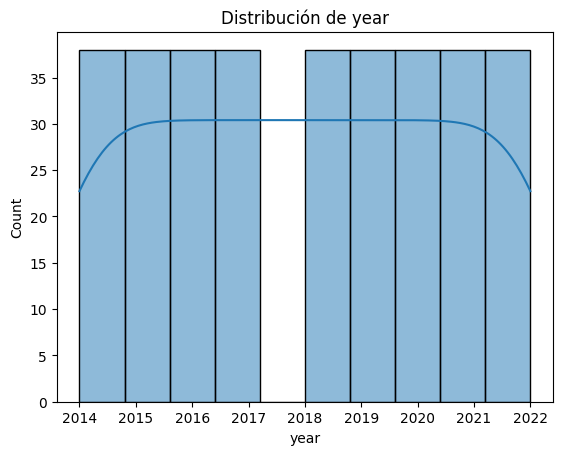

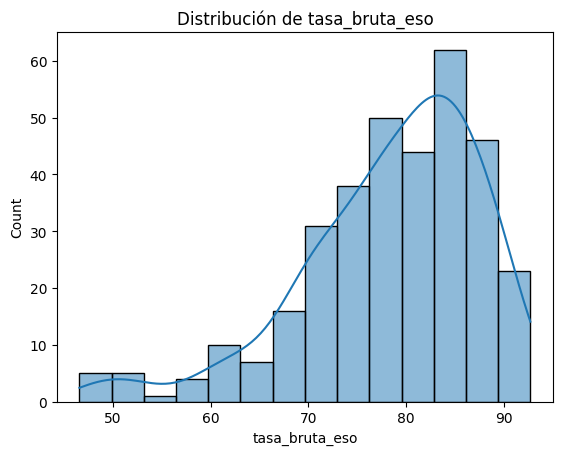

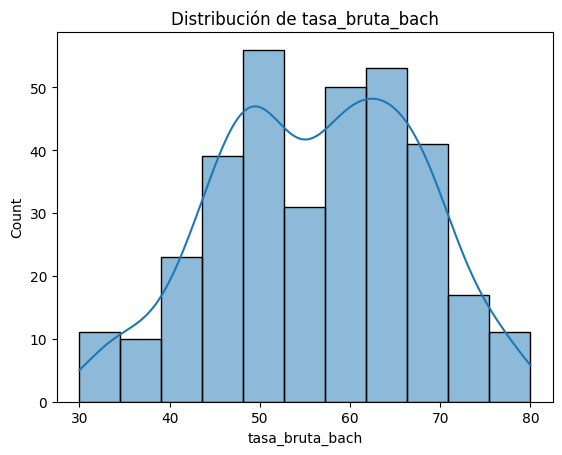

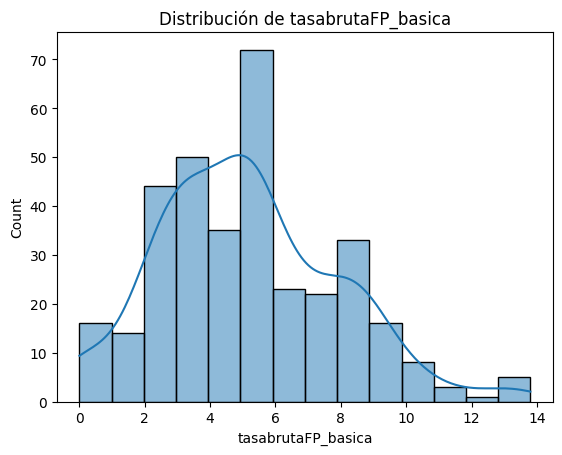

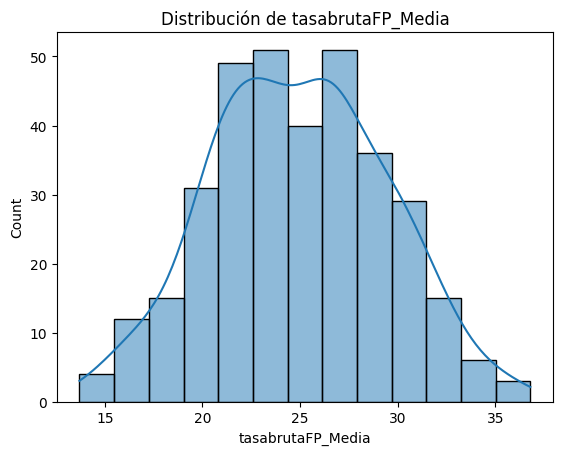

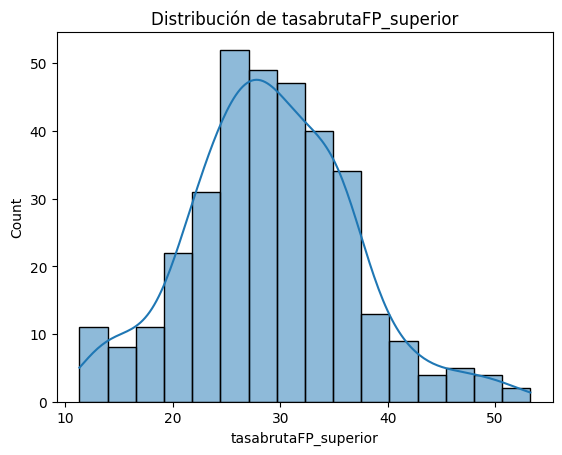

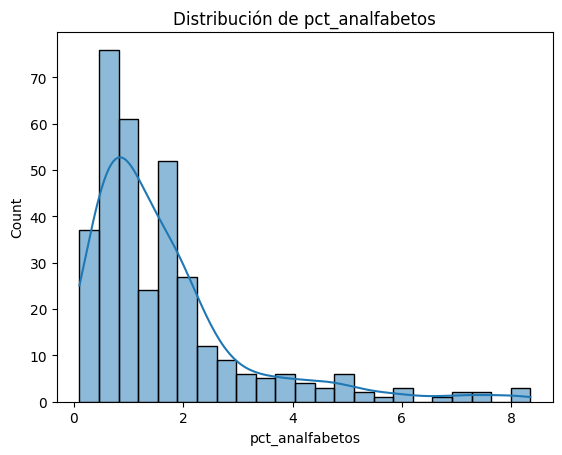

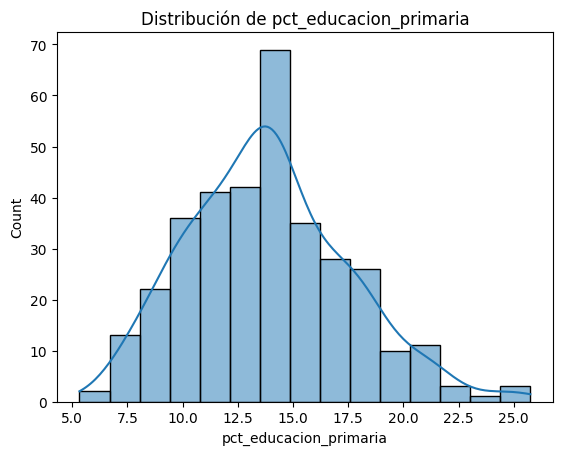

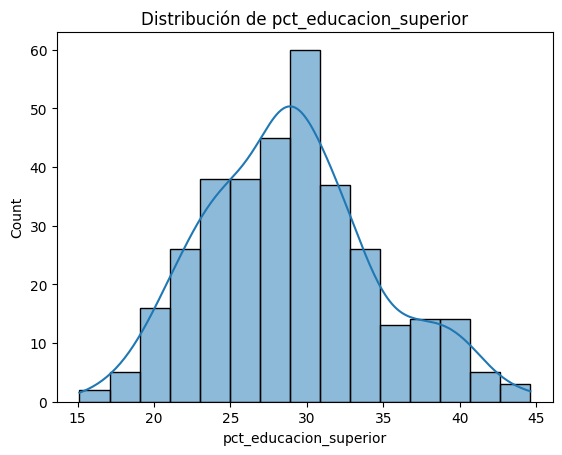

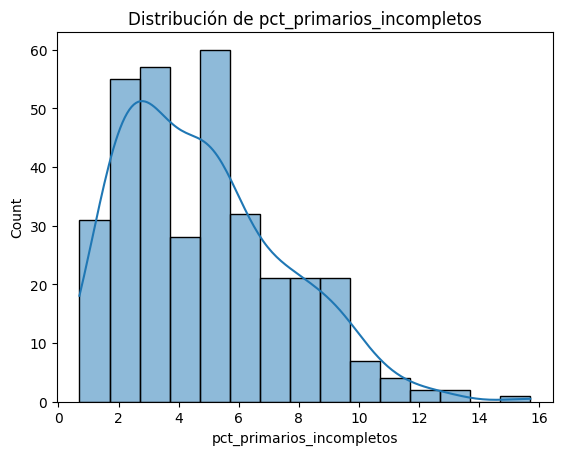

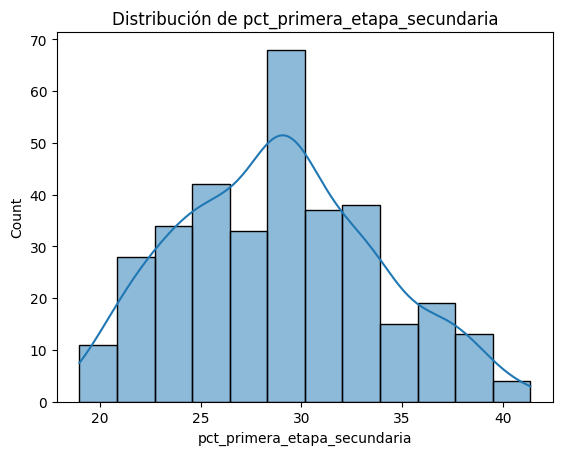

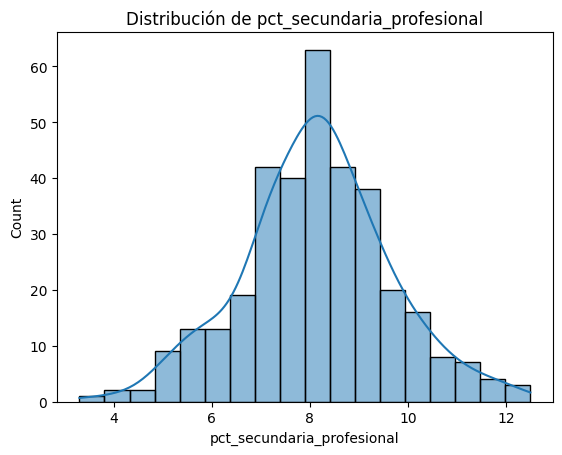

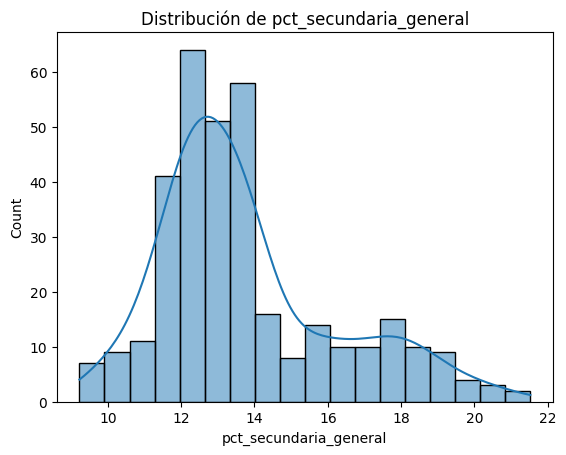

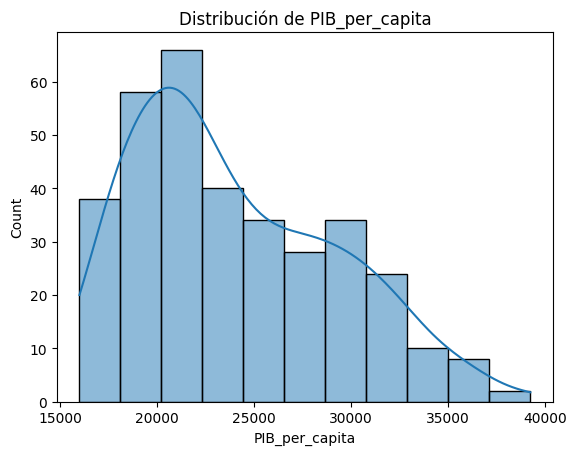

,year,tasa_bruta_eso,tasa_bruta_bach,tasabrutaFP_basica,tasabrutaFP_Media,tasabrutaFP_superior,pct_analfabetos,pct_educacion_primaria,pct_educacion_superior,pct_primarios_incompletos,pct_primera_etapa_secundaria,pct_secundaria_profesional,pct_secundaria_general,PIB_per_capita
ccaa,,,,,,,,,,,,,,
Andalucia,2018.0,78.100000,55.066667,4.087500,23.511111,29.072222,2.900000,12.730556,24.559722,8.487500,31.308333,7.854167,12.168056,18731.222222
Aragon,2018.0,78.166667,58.194444,5.626389,25.994444,29.044444,0.808333,16.327778,29.559722,3.747222,26.009722,9.844444,13.711111,27725.555556
Asturias,2018.0,85.983333,65.711111,2.565278,28.894444,35.655556,0.656944,17.162500,32.077778,3.252778,25.694444,7.980556,13.166667,22202.777778
Canarias,2018.0,80.566667,59.566667,4.187500,24.705556,33.461111,1.891667,13.869444,25.955556,6.619444,27.575000,7.534722,16.556944,19711.666667
Cantabria,2018.0,84.283333,60.550000,4.354167,31.094444,36.522222,0.383333,13.281944,32.059722,1.440278,28.963889,10.454167,13.420833,23165.666667
Castilla La Mancha,2018.0,75.050000,54.933333,5.681944,23.050000,24.400000,1.656019,13.846296,28.910340,4.823611,28.872608,8.125463,13.767052,20288.000000
Castilla y Leon,2018.0,81.938889,61.122222,5.031944,24.266667,29.172222,0.805556,17.587500,27.655556,3.823611,29.226389,8.473611,12.431944,23585.444444
Cataluña,2018.0,84.738889,51.255556,0.593056,28.300000,34.777778,1.401389,14.616667,31.559722,4.981944,27.209722,7.494444,12.730556,29548.000000
Ceuta,2018.0,61.522222,42.061111,6.670833,21.805556,21.150000,3.931944,17.512500,20.894444,3.512500,32.020833,6.116667,16.008333,18768.333333


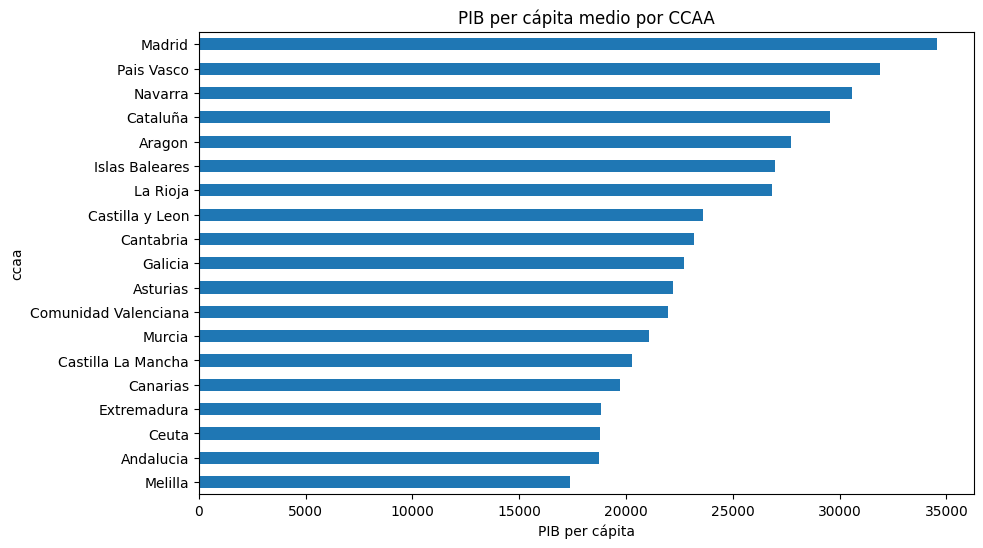

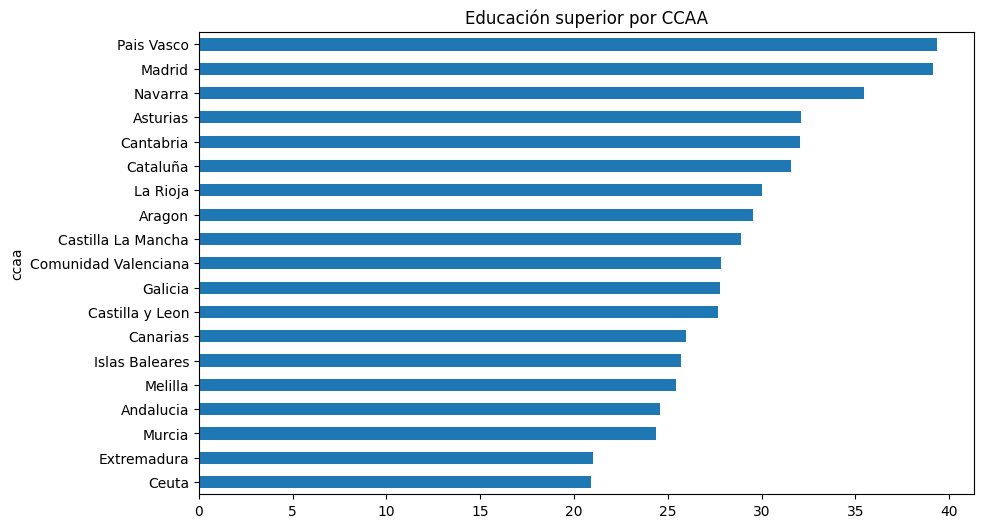

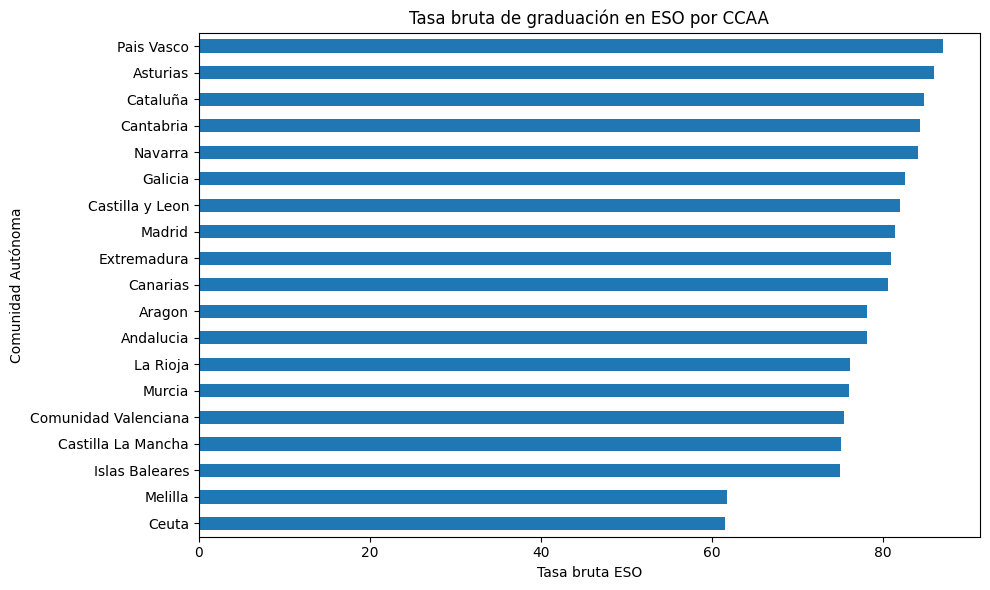

,year,tasa_bruta_eso,tasa_bruta_bach,tasabrutaFP_basica,tasabrutaFP_Media,tasabrutaFP_superior,pct_analfabetos,pct_educacion_primaria,pct_educacion_superior,pct_primarios_incompletos,pct_primera_etapa_secundaria,pct_secundaria_profesional,pct_secundaria_general,PIB_per_capita
sexo,,,,,,,,,,,,,,
hombre,2018.0,73.617544,48.538596,6.710599,25.836842,28.119298,1.113182,12.721150,28.271304,4.122734,31.263909,8.281457,14.226482,24030.736842
mujer,2018.0,83.290643,64.159064,3.564401,24.030409,30.134503,2.198855,14.971442,29.549375,5.524488,26.481307,7.969469,13.307623,24030.736842


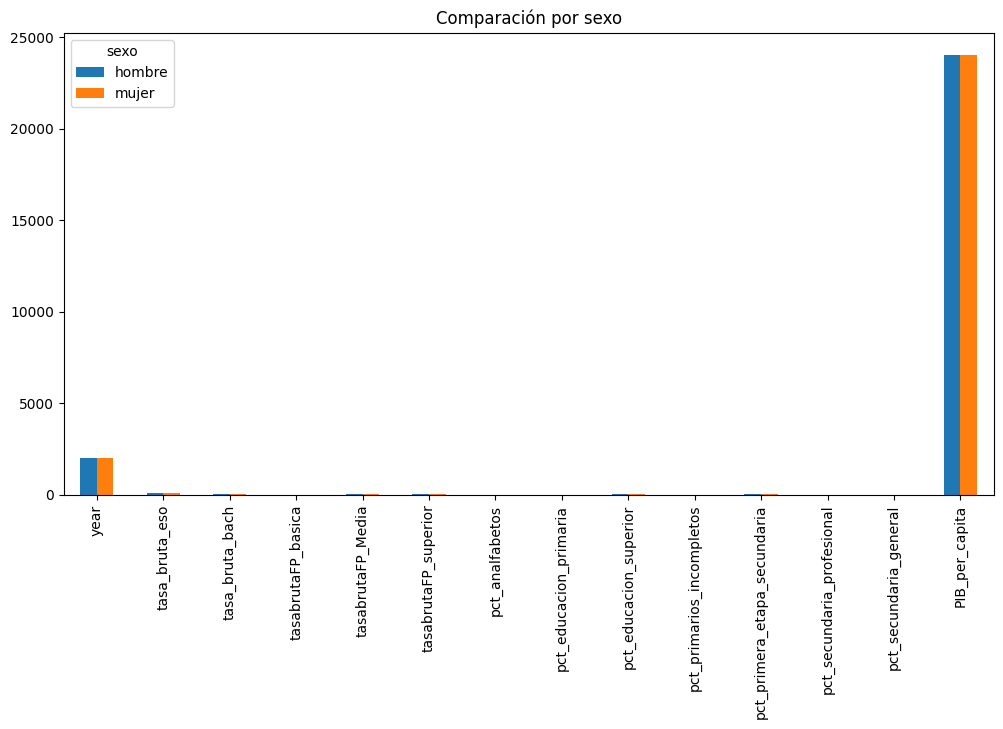

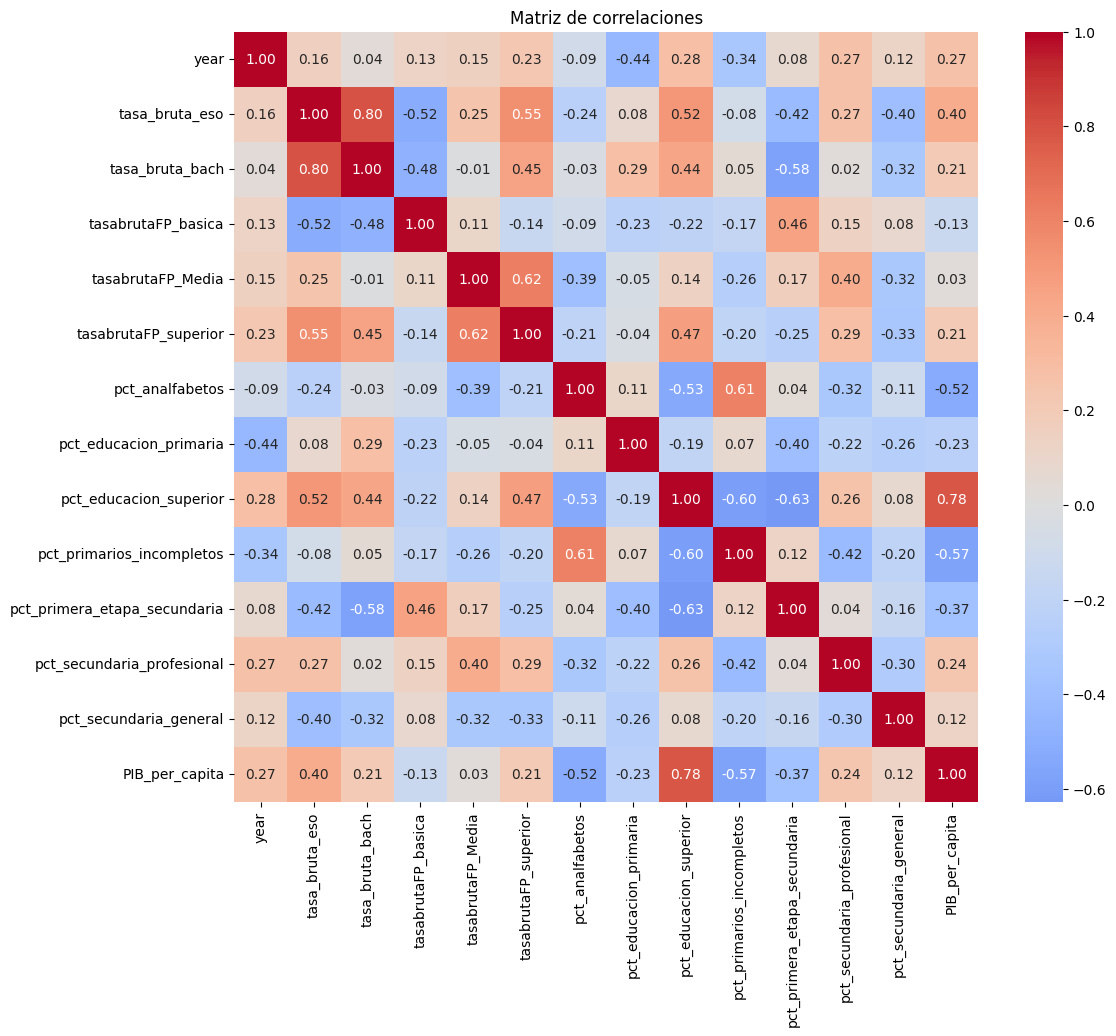

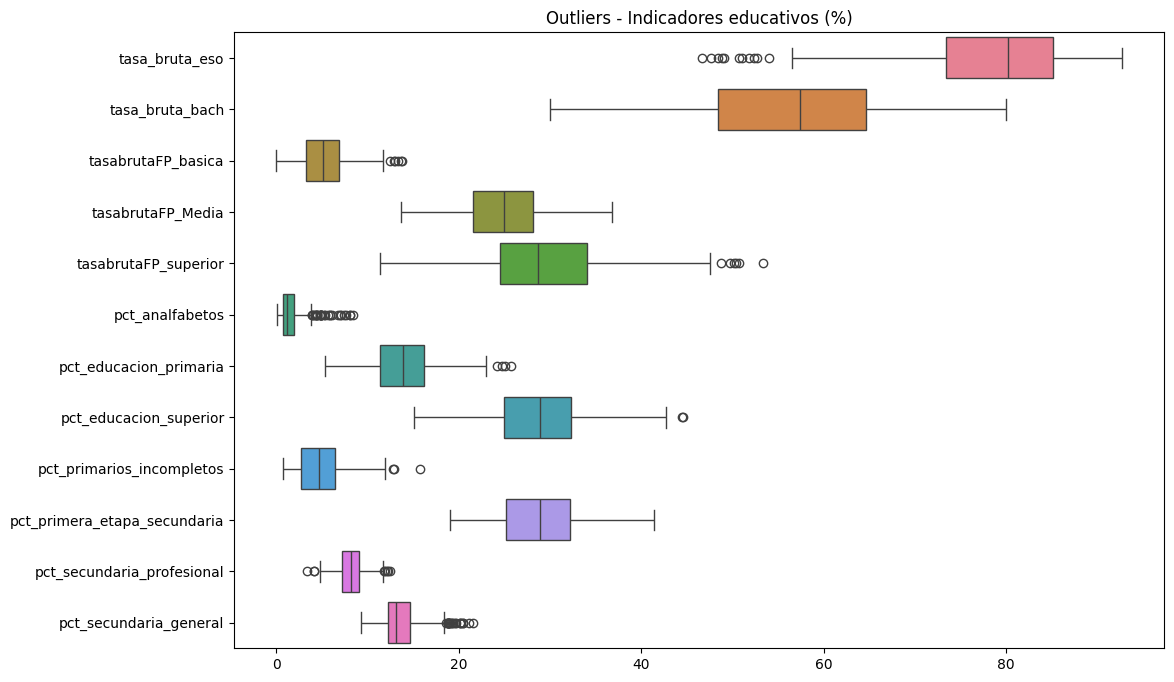

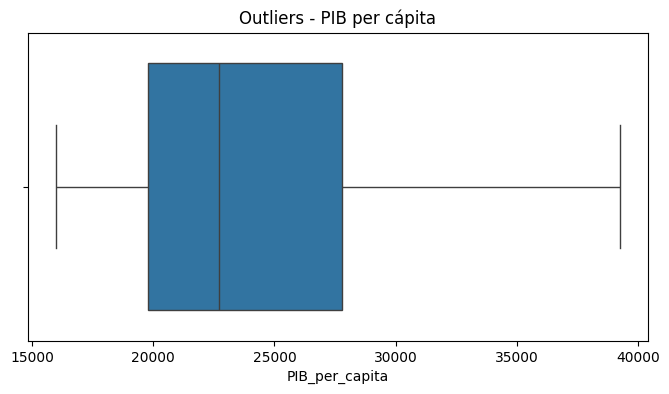

,variable,n_outliers,%_outliers
5,pct_analfabetos,30,8.771930
11,pct_secundaria_general,21,6.140351
0,tasa_bruta_eso,11,3.216374
10,pct_secundaria_profesional,8,2.339181
2,tasabrutaFP_basica,6,1.754386
4,tasabrutaFP_superior,6,1.754386
6,pct_educacion_primaria,4,1.169591
8,pct_primarios_incompletos,3,0.877193
7,pct_educacion_superior,2,0.584795
1,tasa_bruta_bach,0,0.000000


,variable,n_outliers,%_outliers
0,PIB_per_capita,0,0.0


In [ ]:
# 1.VALIDACIÓN DEL DATASET
# Obtenemos su dimensión

print("Dimensiones:", BaseFinal1.shape)

# Verificamos duplicados

print("Duplicados:",BaseFinal1.duplicated().sum())

# Tipos de datos

BaseFinal1.dtypes

# Comprobamos los valores nulos

(BaseFinal1.isnull().sum() / len(BaseFinal1)) * 100

# 2. ANÁLISIS DE DISTRIBUCIONES DE LAS VARIABLES NUMÉRICAS
# Seleccionamos las variables numéricas

numericas = BaseFinal1.select_dtypes(include=['float64', 'int64']).columns

# Realizamos los histogramas

for col in numericas:
    plt.figure()
    sns.histplot(BaseFinal1[col], kde=True)
    plt.title(f"Distribución de {col}")
    plt.show()

# 3. ANÁLISIS DE LAS VARIABLES CATEGÓRICAS
# Análisis por CCAA
# a) Medias de las variables numéricas por CCAA

media_ccaa = BaseFinal1.groupby("ccaa").mean(numeric_only=True)
display(media_ccaa)

# b) PIB per capita medio por CCAA - Visualización

media_ccaa["PIB_per_capita"].sort_values().plot(kind="barh", figsize=(10,6))
plt.title("PIB per cápita medio por CCAA")
plt.xlabel("PIB per cápita")
plt.show()

# c) Media de Educación superior por CCAA - Visualización 

media_ccaa["pct_educacion_superior"].sort_values().plot(kind="barh", figsize=(10,6))
plt.title("Educación superior por CCAA")
plt.show()

# d) Tasa bruta de ESO media por CCAA - Visualización 

media_ccaa["tasa_bruta_eso"].sort_values().plot(kind="barh", figsize=(10,6))
plt.title("Tasa bruta de graduación en ESO por CCAA")
plt.xlabel("Tasa bruta ESO")
plt.ylabel("Comunidad Autónoma")
plt.tight_layout()
plt.show()

# Análisis por sexo

media_sexo = BaseFinal1.groupby("sexo").mean(numeric_only=True)
display(media_sexo)

# a) Comparación por sexo

media_sexo.T.plot(kind="bar", figsize=(12,6))
plt.title("Comparación por sexo")
plt.show()

# 4. ANÁLISIS DE CORRELACIONES
# a) Seleccionamos las variables numéricas

df_num = BaseFinal1.select_dtypes(include=['float64', 'int64'])

# b) Visualizamos la matriz de correlaciones
corr = df_num.corr()

# c) Heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlaciones")
plt.show()

# Más eficiente

# Ver correlaciones más fuertes
corr_unstack = corr.unstack()
corr_unstack = corr_unstack.sort_values(ascending=False)

# Quitamos correlaciones consigo mismas
corr_unstack = corr_unstack[corr_unstack < 1]

corr_unstack.head(10)

# 5. ANÁLISIS DE LOS OUTLIERS
# a) Visualización de los indicadores educativos mediante boxplots

cols_educativas = [
    'tasa_bruta_eso',
    'tasa_bruta_bach',
    'tasabrutaFP_basica',
    'tasabrutaFP_Media',
    'tasabrutaFP_superior',
    'pct_analfabetos',
    'pct_educacion_primaria',
    'pct_educacion_superior',
    'pct_primarios_incompletos',
    'pct_primera_etapa_secundaria',
    'pct_secundaria_profesional',
    'pct_secundaria_general'
]

plt.figure(figsize=(12,8))
sns.boxplot(data=BaseFinal1[cols_educativas], orient='h')
plt.title("Outliers - Indicadores educativos (%)")
plt.show()

# b) Visualización del PIB per capita mediante boxplots

plt.figure(figsize=(8,4))
sns.boxplot(x=BaseFinal1['PIB_per_capita'])
plt.title("Outliers - PIB per cápita")
plt.show()

# c) Detección formal de outliers(IQR)

def outliers_iqr(df, columnas):             # Creamos una función para detectar los outliers
    resultados = []

    for col in columnas:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1                       # Fórmula del rango intercuartílico

        limite_inferior = Q1 - 1.5 * IQR    # < a esto se considera outlier
        limite_superior = Q3 + 1.5 * IQR    # > a esto se considera outlier

        n_outliers = ((df[col] < limite_inferior) | (df[col] > limite_superior)).sum()
        pct_outliers = (n_outliers / len(df)) * 100

        resultados.append({
            "variable": col,
            "numero_outliers": n_outliers,
            "%_outliers": pct_outliers
        })

    return pd.DataFrame(resultados).sort_values("%_outliers", ascending=False)

columnas_educativos = [
    'tasa_bruta_eso', 'tasa_bruta_bach', 'tasabrutaFP_basica',
    'tasabrutaFP_Media', 'tasabrutaFP_superior',
    'pct_analfabetos', 'pct_educacion_primaria',
    'pct_educacion_superior', 'pct_primarios_incompletos',
    'pct_primera_etapa_secundaria', 'pct_secundaria_profesional',
    'pct_secundaria_general'
]

# Visualizamos los outliers en una tabla de los indicadores educativos

tabla_outliers_pct = outliers_iqr(BaseFinal1, columnas_educativos)
display(tabla_outliers_pct)

# Visualizamos  los outliers en una tabla del PIB

tabla_outliers_pib = outliers_iqr(BaseFinal1, ['PIB_per_capita'])
display(tabla_outliers_pib)
